# Diabetes Risk Analysis: The Power of Lifestyle
## Executive Summary

Μετά από ενδελεχή ανάλυση του συνόλου δεδομένων (Data Storytelling & Multivariate Analysis), ανακαλύψαμε 3 κρίσιμα συμπεράσματα:

1. **Το Lifestyle Νικάει την Κληρονομικότητα:** Ασθενείς με οικογενειακό ιστορικό που διατηρούν άριστη ποιότητα ζωής, έχουν χαμηλότερο κίνδυνο από αυτούς χωρίς ιστορικό που κάνουν κακή ζωή. Η Γυμναστική, η Διατροφή και το Στρες είναι οι Νο1 παράγοντες.
2. **Ο Διαβήτης δεν κάνει διακρίσεις (Gender Myth):** Το φύλο δεν παίζει απολύτως κανέναν ρόλο στην αύξηση του κινδύνου.
3. **Η Απόλυτη Αλήθεια του Αίματος:** Η κακή ποιότητα ζωής δεν αυξάνει απλά ένα θεωρητικό σκορ κινδύνου, αλλά αποδεικνύεται ότι εκτοξεύει άμεσα την ίδια την τιμή του σακχάρου στο αίμα (Fasting Blood Sugar).


## 1. Data Import & Preparation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("diabetes_risk_prediction_dataset.csv")


In [2]:
# Data Cleaning (Imputation)
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].fillna('Unknown')
df['Medication_Adherence'] = df['Medication_Adherence'].fillna('Unknown')

df['Exercise_Hours_Per_Week'] = df['Exercise_Hours_Per_Week'].fillna(
    df.groupby('Physical_Activity_Level')['Exercise_Hours_Per_Week'].transform('median')
)

remaining_metric = ['Age', 'Height_cm', 'Weight_kg', 'Blood_Glucose', 'HbA1c', 
                    'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 
                    'Daily_Walking_Minutes', 'Sleep_Hours']
for col in remaining_metric:
    df[col] = df[col].fillna(df[col].median())

# Feature Engineering (Age Groups)
df['Age Group'] = np.select(
    [df['Age']<30, (df['Age']>=30) & (df['Age']<=60), df['Age']>60],
    ['Young','Middle Age','Senior'], default='Unknown'
)

# Feature Engineering (Lifestyle Score 0-3)
df['Lifestyle_Score'] = (
    (df['Diet_Quality'] == 'Healthy').astype(int) + 
    (df['Physical_Activity_Level'] == 'High').astype(int) + 
    (df['Stress_Level'] == 'Low').astype(int)
)


## 2. Exploratory Data Analysis (EDA)
### 2.1 Η Κατάρριψη του Μύθου: Παίζει ρόλο το Φύλο;
Τα δεδομένα αποδεικνύουν ότι ο κίνδυνος είναι σχεδόν ταυτόσημος ανάμεσα στα δύο φύλα. Ο διαβήτης δεν κάνει διακρίσεις.


,Gender,Diabetes_Risk_Score
0,Female,74.09
1,Male,74.04
2,Other,74.00


C:\Users\cris-\AppData\Local\Temp\ipykernel_7744\1204028803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Gender', y='Diabetes_Risk_Score', palette='pastel')


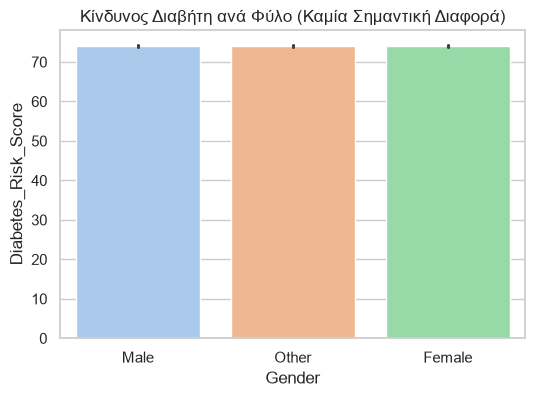

In [3]:
result_gender = df.groupby('Gender')['Diabetes_Risk_Score'].mean().reset_index().round(2)
display(result_gender)

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Gender', y='Diabetes_Risk_Score', palette='pastel')
plt.title('Κίνδυνος Διαβήτη ανά Φύλο (Καμία Σημαντική Διαφορά)')
plt.show()


### 2.2 Η Κλινική Αλήθεια: Πώς η Ηλικία και ο Κίνδυνος εκτοξεύουν το Σάκχαρο
Δεν μιλάμε μόνο για θεωρητικό σκορ κινδύνου. Βλέπουμε πώς οι ίδιοι οι ιατρικοί δείκτες (Ζάχαρο) κλιμακώνονται απότομα καθώς μεγαλώνουμε.


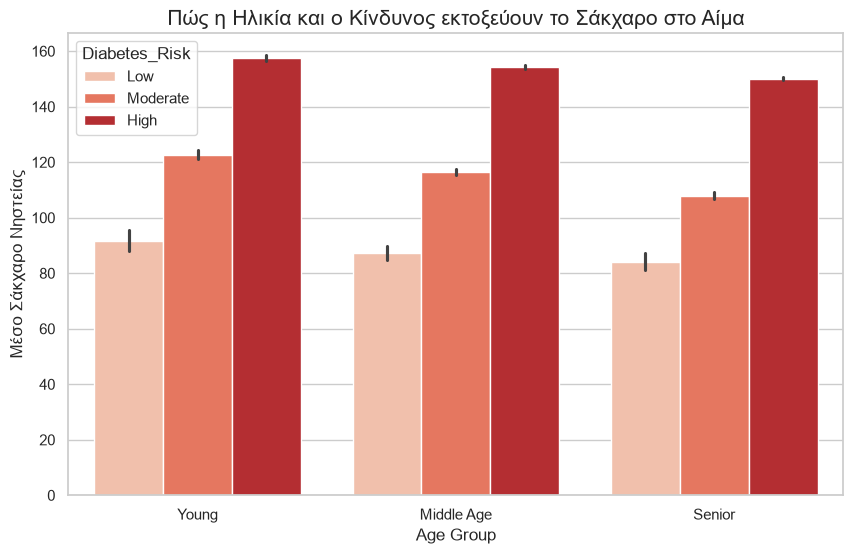

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='Age Group',                 
    y='Fasting_Blood_Sugar',       
    hue='Diabetes_Risk',
    order=['Young', 'Middle Age', 'Senior'],
    hue_order=['Low', 'Moderate', 'High'],
    palette='Reds'
)
plt.title("Πώς η Ηλικία και ο Κίνδυνος εκτοξεύουν το Σάκχαρο στο Αίμα", fontsize=15)
plt.ylabel("Μέσο Σάκχαρο Νηστείας")
plt.show()


### 2.3 The Hero Insight: Lifestyle vs Genetics
Αποδεικνύουμε ότι ένας ασθενής με κληρονομικότητα (DNA) αλλά τέλεια ζωή (Lifestyle Score = 3), έχει λιγότερο κίνδυνο από κάποιον χωρίς κληρονομικότητα που κάνει κακή ζωή (Σκορ = 0).


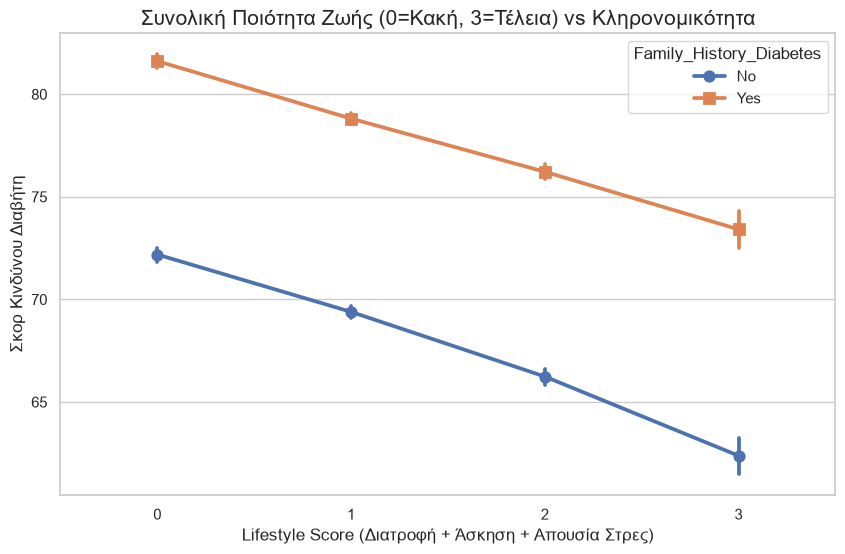

In [5]:
plt.figure(figsize=(10, 6))
sns.pointplot(
    data=df,
    x='Lifestyle_Score',
    y='Diabetes_Risk_Score',
    hue='Family_History_Diabetes',
    markers=['o', 's']
)
plt.title("Συνολική Ποιότητα Ζωής (0=Κακή, 3=Τέλεια) vs Κληρονομικότητα", fontsize=15)
plt.ylabel("Σκορ Κινδύνου Διαβήτη")
plt.xlabel("Lifestyle Score (Διατροφή + Άσκηση + Απουσία Στρες)")
plt.show()


### 2.4 Deep Dive: Πολυπαραγοντική Ανάλυση (Heatmap)
Συνδυάζοντας Κάπνισμα, Κληρονομικότητα, Διατροφή και Άσκηση σε έναν πίνακα, για να εντοπίσουμε τα "επικίνδυνα κόκκινα" σημεία.


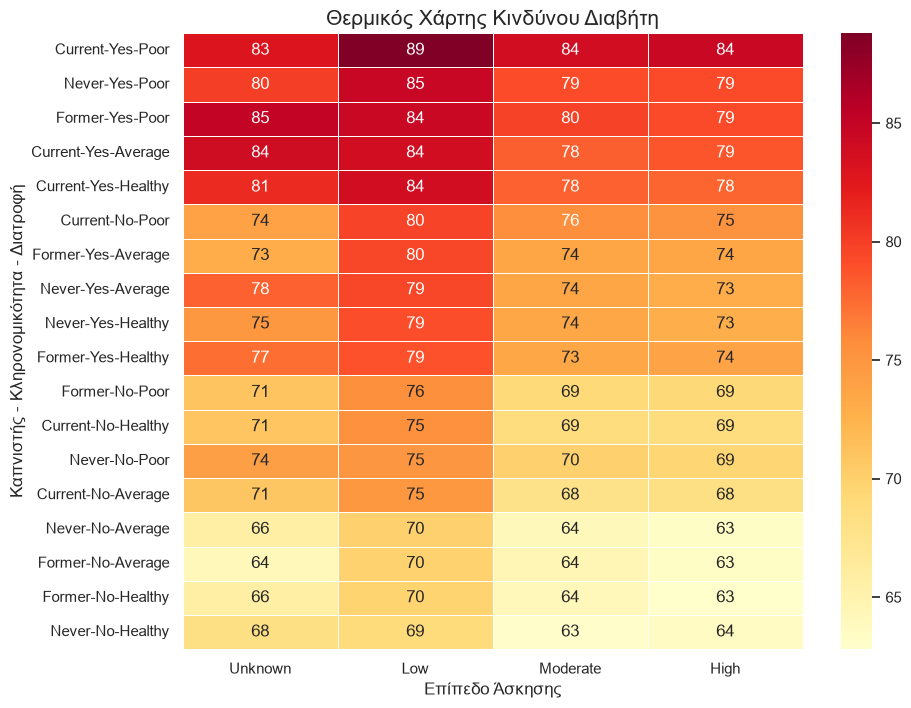

In [6]:
pivot_result2 = pd.pivot_table(
    data=df,
    values='Diabetes_Risk_Score',
    index=['Smoking_Status','Family_History_Diabetes','Diet_Quality'],
    columns='Physical_Activity_Level',
    aggfunc='mean'
).round(2).sort_values(by='Low', ascending=False)

pivot_clean = pivot_result2[['Unknown','Low','Moderate','High']]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_clean, annot=True, cmap='YlOrRd', linewidths=0.5)
plt.title("Θερμικός Χάρτης Κινδύνου Διαβήτη", fontsize=15)
plt.ylabel("Καπνιστής - Κληρονομικότητα - Διατροφή")
plt.xlabel("Επίπεδο Άσκησης")
plt.show()
